In [2]:
pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\agusm\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

sns.set_theme(style="darkgrid")
print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [4]:
df = pd.read_csv('creditcard.csv')

# Features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Scale Amount and Time (the only non-PCA columns)
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

print(f"✅ Dataset ready: {X.shape[0]:,} rows, {X.shape[1]} features")
print(f"🚨 Fraud cases before SMOTE: {y.sum()}")

✅ Dataset ready: 284,807 rows, 30 features
🚨 Fraud cases before SMOTE: 492


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"📊 Training set before SMOTE: {y_train.value_counts().to_dict()}")
print(f"📊 Training set after SMOTE:  {pd.Series(y_train_sm).value_counts().to_dict()}")

📊 Training set before SMOTE: {0: 227451, 1: 394}
📊 Training set after SMOTE:  {0: 227451, 1: 227451}


In [6]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1  # uses all CPU cores
)

print("⏳ Training model... (may take 1-2 minutes)")
model.fit(X_train_sm, y_train_sm)
print("✅ Model trained successfully!")

⏳ Training model... (may take 1-2 minutes)
✅ Model trained successfully!


In [7]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.43      0.88      0.58        98

    accuracy                           1.00     56962
   macro avg       0.71      0.94      0.79     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9836


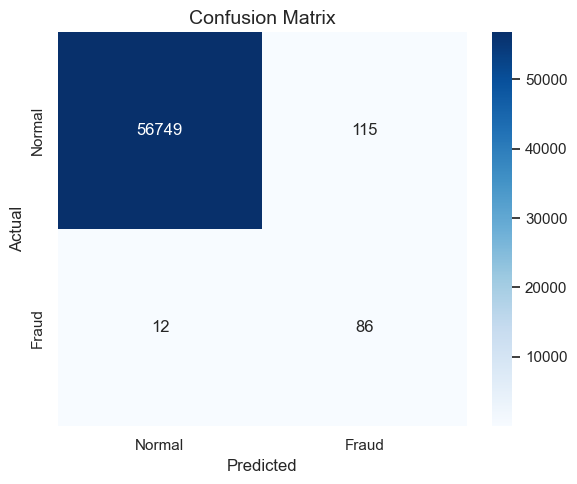

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

This Confusion Matrix shows how my model performed on the test set. To evaluate it properly, I’m looking at the trade-off between security and customer experience.

The Successes: I correctly identified 56,749 legitimate transactions and, more importantly, I caught 86 fraudulent ones.

The Falses Negatives (The Risk): Only 12 frauds 'escaped' the model. From a banking perspective, these are the most dangerous because they represent actual financial loss.

The False Positives (The Friction): I had 115 'false alarms' where the model flagged a normal transaction as fraud. In the real world, this means 115 customers had their cards declined or blocked unnecessarily, which causes friction.

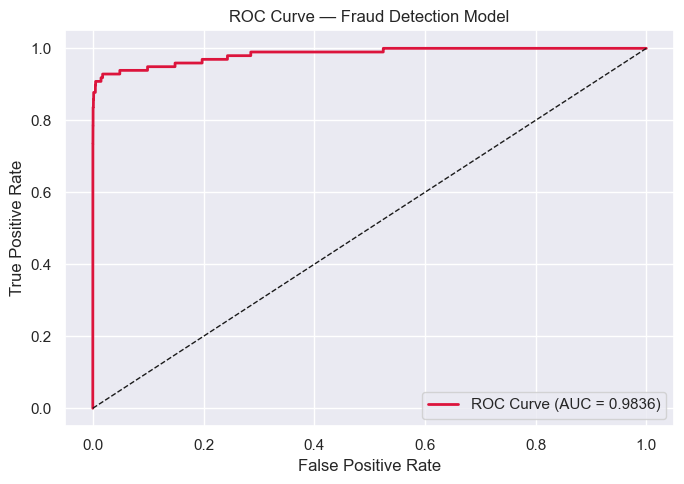

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='crimson', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Fraud Detection Model')
plt.legend()
plt.tight_layout()
plt.show()

Being at 0.98 proves that my Random Forest is highly capable of separating the two classes. It means that if I picked one random fraud and one random normal transaction, there is a 98% chance the model would correctly identify which one is which.

## Export results for Power BI

In [10]:
import os
os.makedirs('outputs', exist_ok=True)

# 1. Predictions file
results = X_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = y_pred
results['Fraud_Probability'] = y_prob
results.to_csv('outputs/predictions.csv', index=False)

# 2. Confusion matrix file
cm_df = pd.DataFrame({
    'Category': ['True Normal', 'False Positive', 'False Negative', 'True Fraud'],
    'Count': [cm[0,0], cm[0,1], cm[1,0], cm[1,1]],
    'Description': [
        'Normal transaction correctly identified',
        'Normal transaction flagged as fraud',
        'Fraud missed by the model',
        'Fraud correctly detected'
    ]
})
cm_df.to_csv('outputs/confusion_matrix.csv', index=False)

# 3. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
importance_df.to_csv('outputs/feature_importance.csv', index=False)

print("✅ Files exported to outputs/")
print("📁 predictions.csv")
print("📁 confusion_matrix.csv")
print("📁 feature_importance.csv")

✅ Files exported to outputs/
📁 predictions.csv
📁 confusion_matrix.csv
📁 feature_importance.csv
